# Experiment: multi-field mixture bank

Build a bank of place-field primitives via base GMM → weighted agglomerative
tree → per-node feature-space σ → per-node environment-space radius →
viability / scale / dedup filters → tree-of-primitives table.

Dataset: `circ_lm8_r0.h5` (cylindrical arena, 8 landmarks, φ = 0°),
`N_COMBINE = 8` (360° pov, concat).

## Reporting conventions

Two neuroscience references use different multi-field summaries:

- **Eliav 2021** — 1D fields in a 200 m bat tunnel. Reports a *length ratio*
  (largest / smallest field) per cell: median ≈ 4.4, tail to 20. Largest
  fields reach 32 m ≈ 16 % of the environment length.
- **Harland 2021** — 2D fields in an 18.6 m² open arena. Reports a per-cell
  *area range* (max − min) > 0.6 m² for 79 % of cells, with absolute areas
  spanning 0.023 – 3.46 m². Largest fields ≈ 19 % of the arena area.

The 2D analogue of Eliav's length ratio is a *radius* ratio, not an area
ratio. So a 4.4× radius ratio equals a 4.4² ≈ 19× area ratio, and a 20×
radius ratio equals a 400× area ratio. Both targets are reported side by
side in the draw simulation (D4) so nothing is hidden by convention choice.

Empirical primitive cap: Harland's largest field is ≈ 19 % of the arena,
Eliav's largest is ≈ 16 %. Rounding up: cap primitives at ≈ 20 % of arena
area. For LM8's ≈ 16 m² sampled area, that is ≈ 3.2 m² → radius ≈ 1.0 m.
Combined with a viability floor at ~0.1 m, the usable bank spans ~10× in
radius and ~100× in area — enough headroom for Eliav's median and most of
its tail.


In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
os.chdir('../..')  # project root

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.style.use('default')
mpl.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'savefig.facecolor': 'white',
})

from realm_tools.experiment_lib.place_cell_analysis import load_condition
from realm_tools.place_cell_lib import VisualPlaceCellEnsemble, rbf_activations
from sklearn.mixture import GaussianMixture

import json
import warnings
warnings.filterwarnings('ignore', category=UserWarning)


## Config

In [2]:
DATA_PATH    = 'data/vpce/collect_data/circ_lm8_r0.h5'
N_COMBINE    = 8                                  # collapse all 8 headings → 360° pov
COMBINE_MODE = 'concat'                           # matches experiment_field_size_sweep

# Base fit
K0           = 750                                # number of GMM leaves
REG_COVAR    = 1e-3
RANDOM_SEED  = 0
TRAIN_FRAC   = 0.5                                # split train/eval halves

# σ per node
SIGMA_PCTL   = 90                                 # percentile of within-cluster pairwise
                                                  # distance — replaces max (100), which is
                                                  # an outlier statistic (one stray sample
                                                  # sets primitive width). 90 is a
                                                  # deliberately mild shrink; drop to 75 if
                                                  # internal nodes still look identical to
                                                  # their children.

# Environment-space readout
GRID_BINS    = 60                                 # 60x60 spatial grid for area readout
ACT_THRESH   = 0.5                                # threshold on minmax-normalised
                                                  #   activation for suprathreshold area

# Filters
MIN_MEMBERS         = 8                            # viability: assigned samples.
                                                   # 8 is enough for a percentile width;
                                                   # below that σ is a coin flip.
MIN_RADIUS_BINS     = 2                            # viability: min radius in grid bins
ARENA_FRAC_CAP      = 0.20                         # scale cap: max area / arena area
DEDUP_CENTROID_FRAC = 0.15                         # dedup: centroid tolerance as fraction of
                                                   # arena *diameter* (2R). Two nodes are
                                                   # duplicates only if within this AND ...
DEDUP_RADIUS_FRAC   = 0.15                         # ... within this fractional radius delta.
                                                   # Preserves scale ladders: parent and
                                                   # child overlap spatially but survive as
                                                   # distinct rungs when radii differ enough.

# Draw simulation targets
N_MEAN_PRIMITIVES = 5                              # per-cell mean field count for pooling draws
N_DRAWS           = 10_000
ELIAV_MEDIAN_RATIO  = 4.4     # radius ratio, per Eliav 2021
ELIAV_TAIL_RATIO    = 20.0
HARLAND_AREA_RANGE  = 0.6     # m² per-cell max−min area target
HARLAND_TARGET_FRAC = 0.79    # share of cells above area-range target

SAVE_DIR = 'analysis/experiment_multi_field_mixture_bank/figures'
BANK_DIR = 'data_cache/multi_field_bank'
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(BANK_DIR, exist_ok=True)

def savefig(name):
    p = os.path.join(SAVE_DIR, name)
    plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='white')
    print(f'Saved → {p}')


## Step 0 — Load features, split train / eval

The tree is fit on the training half only. The environment-space readout
in Step 4 is computed on the *eval* half — a node's spatial footprint is
evaluated on data it has never seen, matching how the bank is later used.


In [3]:
features, xy = load_condition(DATA_PATH, n_combine=N_COMBINE, combine_mode=COMBINE_MODE)
N, D = features.shape
print(f'Locations     : {N}')
print(f'Feature dim D : {D}   (combine_mode={COMBINE_MODE!r}, n_combine={N_COMBINE})')

rng = np.random.default_rng(RANDOM_SEED)
perm     = rng.permutation(N)
n_train  = int(TRAIN_FRAC * N)
idx_tr   = perm[:n_train]
idx_ev   = perm[n_train:]
X_tr, xy_tr = features[idx_tr], xy[idx_tr]
X_ev, xy_ev = features[idx_ev], xy[idx_ev]

arena_radius = float(np.hypot(xy[:, 0], xy[:, 1]).max())
arena_area   = float(np.pi * arena_radius ** 2)
print(f'Train : {len(X_tr)}   Eval : {len(X_ev)}')
print(f'Arena : R = {arena_radius:.3f} m   area = {arena_area:.2f} m²   '
      f'(cap area = {ARENA_FRAC_CAP*arena_area:.2f} m² → cap radius ≈ '
      f'{np.sqrt(ARENA_FRAC_CAP*arena_area/np.pi):.2f} m)')


Locations     : 6919
Feature dim D : 58912   (combine_mode='concat', n_combine=8)


Train : 3459   Eval : 3460
Arena : R = 2.350 m   area = 17.35 m²   (cap area = 3.47 m² → cap radius ≈ 1.05 m)


## Step 1 — Base GMM at K₀

Diag-covariance GMM at K₀ = 750, seeded and warning-silenced. We keep the
component means μ_j, mixture weights π_j, and both hard and soft
assignments; downstream, the tree uses π_j as merge weight and the hard
assignments define each leaf's member set.


In [4]:
print(f'Fitting base GMM at K₀ = {K0}  on {len(X_tr)} training samples ...')
gmm0 = GaussianMixture(
    n_components  = K0,
    covariance_type = 'diag',
    reg_covar     = REG_COVAR,
    random_state  = RANDOM_SEED,
    max_iter      = 200,
    init_params   = 'k-means++',
    verbose       = 0,
)
gmm0.fit(X_tr)
mu0     = gmm0.means_                             # (K0, D)
pi0     = gmm0.weights_                           # (K0,)
resp_tr = gmm0.predict_proba(X_tr)                # (n_train, K0)  soft
hard_tr = resp_tr.argmax(axis=1)                  # (n_train,)     hard
print(f'  converged: {gmm0.converged_}   n_iter = {gmm0.n_iter_}')
print(f'  π summary : min={pi0.min():.4f}  median={np.median(pi0):.4f}  max={pi0.max():.4f}')
_uniq, _cnt = np.unique(hard_tr, return_counts=True)
print(f'  members / leaf : min={_cnt.min()}  median={int(np.median(_cnt))}  max={_cnt.max()}   '
      f'({K0 - len(_uniq)} leaves have 0 hard members)')


Fitting base GMM at K₀ = 750  on 3459 training samples ...


  converged: True   n_iter = 3
  π summary : min=0.0003  median=0.0012  max=0.0035
  members / leaf : min=1  median=4  max=12   (0 leaves have 0 hard members)


## Step 2 — Weighted agglomerative merge (bottom-up)

At each step merge the pair minimising

$$\Delta(a,b) \;=\; \frac{\pi_a\pi_b}{\pi_a+\pi_b} \;\|\mu_a-\mu_b\|^2$$

with

$$\mu \;=\; \frac{\pi_a\mu_a + \pi_b\mu_b}{\pi_a+\pi_b}, \qquad \pi = \pi_a+\pi_b.$$

This is weighted Ward. The merged mean is a responsibility-weighted average
— which is exactly how μ_c is defined at leaf level in a GMM. So tree
internal nodes are the same object as leaves, not a different construction.

`sklearn.AgglomerativeClustering` does not accept sample weights for Ward,
hence the explicit greedy loop below. K₀ = 750 makes this trivial: ~140k
initial pair distances (upper triangle), rebuilt lazily as merges happen.

Output: **2·K₀ − 1** nodes (K₀ leaves + K₀ − 1 internal). Each node stores
`μ`, `π`, its member set of training samples (via merged leaf hard
assignments), and its position in the tree (parent, children, depth).


In [5]:
def weighted_ward_tree(mu, pi, hard_members):
    """Greedy weighted-Ward agglomerative merge over GMM components.

    Parameters
    ----------
    mu           : (K0, D) leaf means
    pi           : (K0,)   leaf weights (mixture weights)
    hard_members : list of length K0 — each entry is an np.ndarray of
                   training-sample indices hard-assigned to that leaf

    Returns
    -------
    nodes : list of dict, length 2*K0 - 1, ordered leaves-first then
            merges in creation order. Each dict has:
              mu, pi, members (np.ndarray),
              parent, children (tuple or None),
              depth (0 at leaves, +1 per merge in the ancestor chain,
                     computed post-hoc),
              is_leaf (bool)
    """
    K0 = len(mu)
    N_nodes = 2 * K0 - 1

    # Preallocate arrays for active nodes. active[i] flags whether node i
    # is still available to merge.
    node_mu       = [np.asarray(m, dtype=np.float64) for m in mu]
    node_pi       = list(map(float, pi))
    node_members  = [np.asarray(m, dtype=np.int64) for m in hard_members]
    node_parent   = [None] * N_nodes
    node_children = [None] * N_nodes
    node_is_leaf  = [True] * N_nodes
    for _ in range(K0 - 1):
        node_mu.append(None)
        node_pi.append(0.0)
        node_members.append(None)
        node_is_leaf.append(False)

    active = list(range(K0))

    # Priority queue of candidate merges. Recompute lazily on each
    # extraction to catch stale (already-merged) entries.
    import heapq
    def delta(a, b):
        pa, pb = node_pi[a], node_pi[b]
        w      = (pa * pb) / (pa + pb) if (pa + pb) > 0 else 0.0
        d2     = float(np.sum((node_mu[a] - node_mu[b]) ** 2))
        return w * d2

    print(f'  seeding heap with C({K0}, 2) = {K0*(K0-1)//2} pairs ...')
    heap = []
    for i in range(K0):
        mi = node_mu[i]
        pi_i = node_pi[i]
        # Vectorised delta over all j > i
        js = np.arange(i + 1, K0)
        if len(js) == 0:
            continue
        mj = np.stack([node_mu[j] for j in js])
        d2 = np.sum((mj - mi) ** 2, axis=1)
        pj = np.array([node_pi[j] for j in js])
        w  = (pi_i * pj) / (pi_i + pj + 1e-300)
        dv = w * d2
        for j, v in zip(js, dv):
            heap.append((float(v), i, int(j)))
    heapq.heapify(heap)

    # Perform K0 - 1 merges
    from time import time
    t0 = time()
    active_set = set(active)
    for merge_idx in range(K0 - 1):
        # Pop until we get a valid pair
        while heap:
            v, a, b = heapq.heappop(heap)
            if a in active_set and b in active_set:
                break
        else:
            raise RuntimeError('heap exhausted before all merges completed')

        new_id           = K0 + merge_idx
        pa, pb           = node_pi[a], node_pi[b]
        node_pi[new_id]  = pa + pb
        node_mu[new_id]  = (pa * node_mu[a] + pb * node_mu[b]) / node_pi[new_id]
        node_members[new_id] = np.concatenate([node_members[a], node_members[b]])
        node_parent[a]   = new_id
        node_parent[b]   = new_id
        node_children[new_id] = (a, b)

        active_set.discard(a)
        active_set.discard(b)
        active_set.add(new_id)

        # Push distances from the new node to every other active node
        others = np.fromiter(active_set - {new_id}, dtype=np.int64)
        if len(others):
            mo = np.stack([node_mu[o] for o in others])
            po = np.array([node_pi[o] for o in others])
            d2 = np.sum((mo - node_mu[new_id]) ** 2, axis=1)
            w  = (node_pi[new_id] * po) / (node_pi[new_id] + po)
            dv = w * d2
            for o, val in zip(others, dv):
                heapq.heappush(heap, (float(val), int(min(o, new_id)),
                                                 int(max(o, new_id))))

        if (merge_idx + 1) % max(1, (K0 - 1) // 10) == 0:
            print(f'    merged {merge_idx+1}/{K0-1}  active={len(active_set)}  '
                  f'elapsed={time()-t0:.1f}s')

    # Post-hoc: compute depth of each node (leaves = 0, +1 per merge above)
    depth = [0] * N_nodes
    for nid in range(K0, N_nodes):
        a, b = node_children[nid]
        depth[nid] = 1 + max(depth[a], depth[b])

    nodes = []
    for nid in range(N_nodes):
        nodes.append({
            'node_id'  : nid,
            'mu'       : node_mu[nid],
            'pi'       : node_pi[nid],
            'members'  : node_members[nid],
            'parent'   : node_parent[nid],
            'children' : node_children[nid],
            'depth'    : depth[nid],
            'is_leaf'  : node_is_leaf[nid],
        })
    return nodes


In [6]:
# Materialise per-leaf member index lists from hard assignments on the
# training half. Empty leaves get an empty index array — they will be
# filtered later in Step 5 by viability.
hard_members = [np.where(hard_tr == k)[0] for k in range(K0)]

nodes = weighted_ward_tree(mu0, pi0, hard_members)
print(f'Total tree nodes : {len(nodes)}   '
      f'(leaves = {K0}, internal = {K0 - 1})')
print(f'Max depth        : {max(n["depth"] for n in nodes)}')


  seeding heap with C(750, 2) = 280875 pairs ...


    merged 74/749  active=676  elapsed=20.4s


    merged 148/749  active=602  elapsed=35.8s


    merged 222/749  active=528  elapsed=230.2s


    merged 296/749  active=454  elapsed=245.7s


...

    merged 444/749  active=306  elapsed=264.8s


    merged 518/749  active=232  elapsed=271.4s


    merged 592/749  active=158  elapsed=276.5s


    merged 666/749  active=84  elapsed=280.4s


    merged 740/749  active=10  elapsed=281.9s
Total tree nodes : 1499   (leaves = 750, internal = 749)
Max depth        : 13


## Step 3 — Feature-space σ per node

Node σ = **percentile** of pairwise distances within the node's
training-sample member set, not the max. Max-pairwise is an outlier
statistic: a single stray sample sets the primitive width. That inflates
σ for internal nodes, makes their spatial mask nearly identical to their
children's, and collapses the tree at dedup.

`SIGMA_PCTL = 90` is a mild shrink; use 75 for more aggressive, or a
fixed multiple of RMS radius if percentile still overshoots.

The Gram trick still stands:

$$D^2_{ij} = \|x_i\|^2 + \|x_j\|^2 - 2\,x_i^\top x_j$$

For n_train ≈ N/2 samples we get an n × n matrix, ~50 MB in float32. σ
for any node is then a percentile over the upper triangle of the submatrix
indexed by its members.


In [7]:
print('Precomputing pairwise squared distances on training samples ...')
Xtr32 = X_tr.astype(np.float32, copy=False)
sq    = np.sum(Xtr32 ** 2, axis=1)
D2    = sq[:, None] + sq[None, :] - 2.0 * (Xtr32 @ Xtr32.T)
np.maximum(D2, 0, out=D2)                          # clip fp noise below zero
print(f'  D2 shape={D2.shape}  dtype={D2.dtype}  MB={D2.nbytes/1e6:.1f}')

def node_sigma(members, pctl=SIGMA_PCTL):
    if len(members) < 2:
        return 0.0
    sub = D2[np.ix_(members, members)]
    # upper triangle (excl. diagonal) — the actual pairwise distances
    n  = len(members)
    iu = np.triu_indices(n, k=1)
    d  = np.sqrt(sub[iu])
    return float(np.percentile(d, pctl))

for nd in nodes:
    nd['sigma'] = node_sigma(nd['members'])

sigmas = np.array([nd['sigma'] for nd in nodes])
print(f'σ across all nodes (P{SIGMA_PCTL}): min={sigmas.min():.3f}  '
      f'median={np.median(sigmas):.3f}  max={sigmas.max():.3f}   '
      f'(zeros = {(sigmas == 0).sum()})')


Precomputing pairwise squared distances on training samples ...


  D2 shape=(3459, 3459)  dtype=float32  MB=47.9


σ across all nodes (P90): min=0.000  median=5368.030  max=12844.273   (zeros = 57)


## Step 4 — Environment-space radius per node

For each node compute activation on the *eval half* using μ_node, σ_node.
Bin activations to a `GRID_BINS × GRID_BINS` spatial grid on `(x, y)`.
Threshold at `ACT_THRESH` on the per-cell minmax-normalised activation
(unit-free — a node with wildly different absolute scale is on the same
footing as any other). Suprathreshold area = number of grid cells above
threshold × bin_area. Radius = √(A/π).

`(σ_node, A_node, r_node, mask_indices)` is cached so downstream filters
(IoU dedup) and diagnostics don't have to recompute.


In [8]:
# Build a rectangular grid covering the sampled xy extent.
x_min, x_max = xy[:, 0].min(), xy[:, 0].max()
y_min, y_max = xy[:, 1].min(), xy[:, 1].max()
x_edges = np.linspace(x_min, x_max, GRID_BINS + 1)
y_edges = np.linspace(y_min, y_max, GRID_BINS + 1)
bin_area = (x_edges[1] - x_edges[0]) * (y_edges[1] - y_edges[0])
print(f'Grid : {GRID_BINS}×{GRID_BINS}   bin_area = {bin_area*1e4:.2f} cm²')

# Precompute which grid bin each eval sample falls into, and mask of bins
# inside the arena disc (so "suprathreshold area" refers to arena bins only).
ix_ev = np.clip(np.searchsorted(x_edges, xy_ev[:, 0], side='right') - 1, 0, GRID_BINS - 1)
iy_ev = np.clip(np.searchsorted(y_edges, xy_ev[:, 1], side='right') - 1, 0, GRID_BINS - 1)

xc = 0.5 * (x_edges[:-1] + x_edges[1:])
yc = 0.5 * (y_edges[:-1] + y_edges[1:])
GX, GY = np.meshgrid(xc, yc, indexing='ij')
arena_mask = (GX ** 2 + GY ** 2) <= arena_radius ** 2
arena_bins = int(arena_mask.sum())
print(f'Bins inside arena disc : {arena_bins}   '
      f'total arena area from bins ≈ {arena_bins*bin_area:.2f} m²')


def env_readout_batch(mus, sigmas, X_eval, ix, iy, batch=64):
    """Return per-node (area, radius, peak_bin_flat) computed on eval samples.

    Batches over primitives to keep memory bounded on high-D features."""
    n_nodes = len(mus)
    A = np.zeros(n_nodes)
    R = np.zeros(n_nodes)
    peak_flat = np.zeros(n_nodes, dtype=np.int64)
    masks = [None] * n_nodes

    Xe = X_eval.astype(np.float64, copy=False)
    Xe_sq = (Xe ** 2).sum(axis=1)

    for start in range(0, n_nodes, batch):
        stop = min(start + batch, n_nodes)
        M    = np.stack(mus[start:stop])                   # (b, D)
        S    = np.array(sigmas[start:stop])                # (b,)
        # dist² = ||x||² - 2 x·μ + ||μ||²
        M_sq = (M ** 2).sum(axis=1)
        d2   = Xe_sq[:, None] - 2.0 * (Xe @ M.T) + M_sq[None, :]
        np.maximum(d2, 0, out=d2)
        # RBF response; σ = 0 → response only at exact centre → all zeros
        # (below threshold). Clamp σ to a tiny floor to avoid div-by-zero.
        S_safe = np.where(S > 0, S, 1.0)
        raw = np.exp(-d2 / (2.0 * S_safe[None, :] ** 2))    # (n_eval, b)

        # Per-column minmax
        col_min = raw.min(axis=0, keepdims=True)
        col_max = raw.max(axis=0, keepdims=True)
        span    = col_max - col_min
        norm    = (raw - col_min) / np.where(span == 0, 1, span)

        # Accumulate per-bin max activation, then threshold.
        for j in range(stop - start):
            nid = start + j
            grid = np.zeros((GRID_BINS, GRID_BINS), dtype=np.float64)
            # take per-bin MAX, not mean — matches the peak-response
            # "place field" definition
            np.maximum.at(grid, (ix, iy), norm[:, j])
            supra = (grid >= ACT_THRESH) & arena_mask
            n_bins = int(supra.sum())
            A[nid] = n_bins * bin_area
            R[nid] = np.sqrt(A[nid] / np.pi) if n_bins else 0.0
            peak_flat[nid] = int(np.argmax(grid))
            masks[nid] = supra

        if ((start // batch) + 1) % 20 == 0 or stop == n_nodes:
            print(f'  env readout : {stop}/{n_nodes}')
    return A, R, peak_flat, masks


mus_all    = [nd['mu']    for nd in nodes]
sigmas_all = [nd['sigma'] for nd in nodes]

print(f'Computing env-space radius for {len(nodes)} nodes ...')
A_all, R_all, peak_flat_all, masks_all = env_readout_batch(
    mus_all, sigmas_all, X_ev, ix_ev, iy_ev, batch=64,
)

for nd, a, r, pf, mk in zip(nodes, A_all, R_all, peak_flat_all, masks_all):
    nd['area_env']  = float(a)
    nd['radius_env'] = float(r)
    nd['peak_flat'] = int(pf)
    nd['mask']      = mk  # kept transient for the IoU step; not persisted

print(f'radius_env  : min={R_all.min():.3f}  '
      f'median={np.median(R_all):.3f}  max={R_all.max():.3f}   '
      f'({(R_all == 0).sum()} nodes with zero area)')


Grid : 60×60   bin_area = 60.06 cm²
Bins inside arena disc : 2883   total arena area from bins ≈ 17.32 m²
Computing env-space radius for 1499 nodes ...


  env readout : 1280/1499


  env readout : 1499/1499
radius_env  : min=0.000  median=0.290  max=1.913   (57 nodes with zero area)


## Step 5 — Filters

Applied in order; a per-filter survivor count is printed so the funnel is
visible.

| Filter        | Rule                                                                                                                | Purpose                                          |
|---------------|---------------------------------------------------------------------------------------------------------------------|--------------------------------------------------|
| Viability     | ≥ MIN_MEMBERS assigned samples AND radius ≥ MIN_RADIUS_BINS × bin                                                    | Removes degenerate near-empty leaves             |
| Scale cap     | area ≤ ARENA_FRAC_CAP × arena_area (≈ 20 % of arena)                                                                 | Excludes near-global nodes                       |
| Dedup         | drop if a surviving node is within DEDUP_CENTROID_FRAC × 2R in centroid AND within DEDUP_RADIUS_FRAC in relative radius | Kills near-duplicates in (centroid, scale) space |

The old spatial-IoU-against-parent test collapsed the tree wherever
everything overlapped — a large node and its smaller child are always
mostly the same mask, which is exactly the scale ladder we want to keep.
The new test compares in the joint (centroid, radius) space: parent and
child both survive if their radii differ by more than `DEDUP_RADIUS_FRAC`.


In [9]:
min_r_env    = MIN_RADIUS_BINS * np.sqrt(bin_area / np.pi)
cap_area     = ARENA_FRAC_CAP * arena_area
cap_r        = np.sqrt(cap_area / np.pi)
cent_tol_abs = DEDUP_CENTROID_FRAC * (2 * arena_radius)
print(f'Viability : ≥ {MIN_MEMBERS} members  AND  radius ≥ {min_r_env:.3f} m')
print(f'Scale cap : area ≤ {cap_area:.2f} m²  (radius ≤ {cap_r:.2f} m)')
print(f'Dedup     : Δcentroid ≤ {cent_tol_abs:.3f} m ({DEDUP_CENTROID_FRAC*100:.0f}% of 2R)  '
      f'AND  |Δr|/max(r) ≤ {DEDUP_RADIUS_FRAC*100:.0f}%')


def _centroid_xy(nd):
    pi_idx, pj_idx = np.unravel_index(nd['peak_flat'], (GRID_BINS, GRID_BINS))
    return float(xc[pi_idx]), float(yc[pj_idx])


def apply_filters(nodes):
    N_total = len(nodes)

    # Filter A: viability
    viable = [nd['node_id'] for nd in nodes
              if len(nd['members']) >= MIN_MEMBERS and nd['radius_env'] >= min_r_env]
    print(f'  after viability : {len(viable):5d} / {N_total}')

    # Filter B: scale cap
    scaled = [nid for nid in viable if nodes[nid]['area_env'] <= cap_area]
    print(f'  after scale cap : {len(scaled):5d} / {N_total}')

    # Filter C: dedup in (centroid, radius) space.
    # Smallest-radius first: small-scale primitives claim their
    # (centroid, radius) neighbourhood; a larger sibling only survives
    # if its radius differs enough to count as a distinct scale rung.
    ordered = sorted(scaled, key=lambda nid: nodes[nid]['radius_env'])
    kept    = []
    kept_c  = np.empty((0, 2))
    kept_r  = np.empty((0,))
    for nid in ordered:
        nd = nodes[nid]
        cx, cy = _centroid_xy(nd)
        r      = nd['radius_env']
        if len(kept):
            d_c = np.hypot(kept_c[:, 0] - cx, kept_c[:, 1] - cy)
            d_r = np.abs(kept_r - r) / np.maximum(kept_r, r)
            if np.any((d_c <= cent_tol_abs) & (d_r <= DEDUP_RADIUS_FRAC)):
                continue
        kept.append(nid)
        kept_c = np.vstack([kept_c, [cx, cy]])
        kept_r = np.append(kept_r, r)
    print(f'  after dedup     : {len(kept):5d} / {N_total}')
    return kept


kept_ids = apply_filters(nodes)
print(f'Surviving primitives : {len(kept_ids)}')


Viability : ≥ 8 members  AND  radius ≥ 0.087 m
Scale cap : area ≤ 3.47 m²  (radius ≤ 1.05 m)
Dedup     : Δcentroid ≤ 0.705 m (15% of 2R)  AND  |Δr|/max(r) ≤ 15%
  after viability :   699 / 1499
  after scale cap :   571 / 1499
  after dedup     :   123 / 1499
Surviving primitives : 123


## Step 6 — Bank schema

One row per surviving primitive. `parent_id` / `child_ids` refer to the
*pre-filter* tree; downstream code that needs a filtered-only tree can
re-derive it by taking the transitive closure through non-surviving nodes.

`data_cache/multi_field_bank/bank.csv` is the artifact all downstream
experiments load.


In [10]:
kept_set = set(kept_ids)

rows = []
for nid in kept_ids:
    nd = nodes[nid]
    ch = nd['children']
    child_ids = list(ch) if ch is not None else []
    # centroid = peak grid bin (unravel from flat index)
    pi_idx, pj_idx = np.unravel_index(nd['peak_flat'], (GRID_BINS, GRID_BINS))
    rows.append({
        'node_id'      : nid,
        'depth'        : nd['depth'],
        'n_members'    : int(len(nd['members'])),
        'pi'           : float(nd['pi']),
        'sigma_feature': float(nd['sigma']),
        'area_env_m2'  : float(nd['area_env']),
        'radius_env_m' : float(nd['radius_env']),
        'centroid_x'   : float(xc[pi_idx]),
        'centroid_y'   : float(yc[pj_idx]),
        'parent_id'    : nd['parent'] if nd['parent'] is not None else -1,
        'child_ids'    : ','.join(str(c) for c in child_ids),
        'is_leaf'      : bool(nd['is_leaf']),
    })

bank_df = pd.DataFrame(rows).sort_values('radius_env_m').reset_index(drop=True)

# Persist bank + means array + config snapshot. CSV chosen over parquet so
# the pipeline has no pyarrow/fastparquet dependency; the schema round-trips
# losslessly because every column is a scalar or a pre-stringified list.
bank_path = os.path.join(BANK_DIR, 'bank.csv')
bank_df.to_csv(bank_path, index=False)
mu_out    = np.stack([nodes[nid]['mu'] for nid in kept_ids]).astype(np.float32)
np.save(os.path.join(BANK_DIR, 'bank_mu.npy'), mu_out)
np.save(os.path.join(BANK_DIR, 'bank_node_ids.npy'), np.array(kept_ids, dtype=np.int64))
with open(os.path.join(BANK_DIR, 'bank_config.json'), 'w') as f:
    json.dump({
        'DATA_PATH': DATA_PATH, 'N_COMBINE': N_COMBINE, 'COMBINE_MODE': COMBINE_MODE,
        'K0': K0, 'REG_COVAR': REG_COVAR, 'RANDOM_SEED': RANDOM_SEED,
        'TRAIN_FRAC': TRAIN_FRAC, 'SIGMA_PCTL': SIGMA_PCTL,
        'GRID_BINS': GRID_BINS, 'ACT_THRESH': ACT_THRESH,
        'MIN_MEMBERS': MIN_MEMBERS, 'MIN_RADIUS_BINS': MIN_RADIUS_BINS,
        'ARENA_FRAC_CAP': ARENA_FRAC_CAP,
        'DEDUP_CENTROID_FRAC': DEDUP_CENTROID_FRAC,
        'DEDUP_RADIUS_FRAC': DEDUP_RADIUS_FRAC,
        'arena_radius_m': arena_radius, 'arena_area_m2': arena_area,
        'n_train': int(len(X_tr)), 'n_eval': int(len(X_ev)),
    }, f, indent=2)
print(f'Bank saved → {bank_path}   rows = {len(bank_df)}')
print(f'μ array   → {os.path.join(BANK_DIR, "bank_mu.npy")}   shape = {mu_out.shape}')
bank_df.head()


Bank saved → data_cache/multi_field_bank/bank.csv   rows = 123
μ array   → data_cache/multi_field_bank/bank_mu.npy   shape = (123, 58912)


,node_id,depth,n_members,pi,sigma_feature,area_env_m2,radius_env_m,centroid_x,centroid_y,parent_id,child_ids,is_leaf
0,806,2,8,0.002313,4778.786719,0.102106,0.180282,-1.64125,-1.56375,1105,"541,752",True
1,848,1,8,0.002313,5107.962207,0.120125,0.195543,1.53625,-1.71875,1250,"49,270",True
2,1141,2,8,0.002313,7466.593115,0.126131,0.200372,-2.10625,-0.86625,1342,"461,808",True
3,990,1,10,0.002891,5773.110449,0.132138,0.205087,-1.71875,1.53625,1255,"51,554",True
4,1000,2,9,0.002602,6590.817139,0.138144,0.209696,-2.26125,-0.16875,1253,"206,753",True


## Step 7 — Diagnostics

D1 scale spectrum · D2 marginal fits · D3 violin by scale · D4 draw
simulation with Eliav + Harland targets · D5 spatial dispersion.


### D1 — Scale spectrum

Histogram of primitive radius (m) and area (m²) across the bank on a log
x-axis. Adjacent radius quantiles jumping by more than ~2× signals a gap
in coverage.


Saved → analysis/experiment_multi_field_mixture_bank/figures/D1_scale_spectrum.png


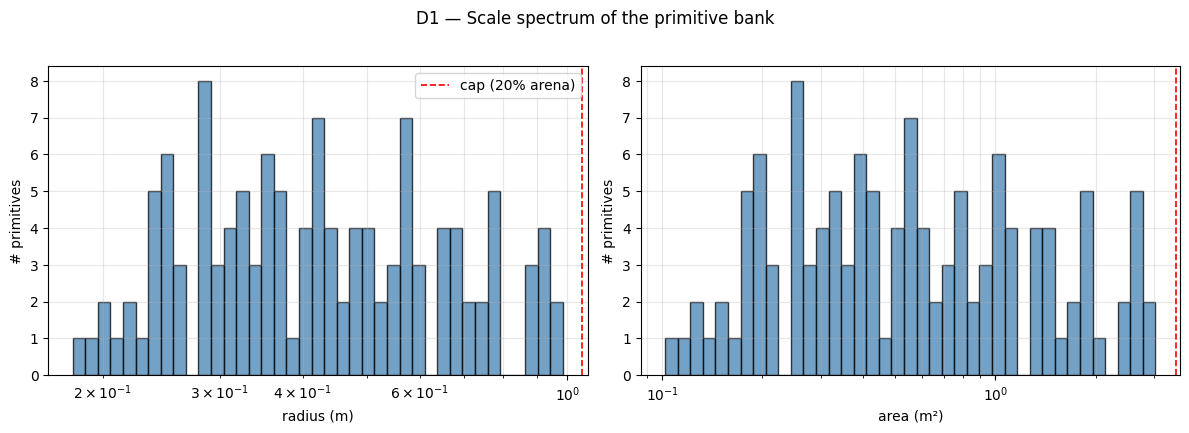

Median adjacent-quantile radius ratio : 1.08× (max = 1.15×)
  ✓ coverage continuous (all adjacent-quantile ratios ≤ 2×)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
rr = bank_df['radius_env_m'].to_numpy()
aa = bank_df['area_env_m2'].to_numpy()

for ax, x, label in [(axes[0], rr, 'radius (m)'),
                     (axes[1], aa, 'area (m²)')]:
    bins = np.logspace(np.log10(max(x.min(), 1e-3)),
                       np.log10(x.max() * 1.01), 40)
    ax.hist(x, bins=bins, color='steelblue', edgecolor='black', alpha=0.75)
    ax.set_xscale('log')
    ax.set_xlabel(label)
    ax.set_ylabel('# primitives')
    ax.grid(alpha=0.3, which='both')

axes[0].axvline(np.sqrt(ARENA_FRAC_CAP * arena_area / np.pi),
                color='red', ls='--', lw=1.2, label=f'cap ({ARENA_FRAC_CAP*100:.0f}% arena)')
axes[0].legend()
axes[1].axvline(ARENA_FRAC_CAP * arena_area, color='red', ls='--', lw=1.2)
fig.suptitle('D1 — Scale spectrum of the primitive bank', y=1.02)
plt.tight_layout(); savefig('D1_scale_spectrum.png'); plt.show()

# Quantile-jump check
q = np.linspace(0.05, 0.95, 19)
rq = np.quantile(rr, q)
ratios = rq[1:] / rq[:-1]
print(f'Median adjacent-quantile radius ratio : {np.median(ratios):.2f}× '
      f'(max = {ratios.max():.2f}×)')
if ratios.max() > 2.0:
    print(f'  ⚠  gap detected — largest jump at quantile '
          f'{q[np.argmax(ratios)+1]:.2f}: {ratios.max():.2f}×')
else:
    print('  ✓ coverage continuous (all adjacent-quantile ratios ≤ 2×)')


### D2 — Marginal fits

Fit log-normal, gamma, and exponential to the bank's *area* distribution;
compare via log-likelihood on the raw values. Eliav found field length
well fit by log-normal, so this is the reference. If the uniform-over-nodes
bank already produces a log-normal-shaped area marginal we should touch
nothing — reweighting it would be curve-fitting.


Saved → analysis/experiment_multi_field_mixture_bank/figures/D2_area_marginal_fits.png


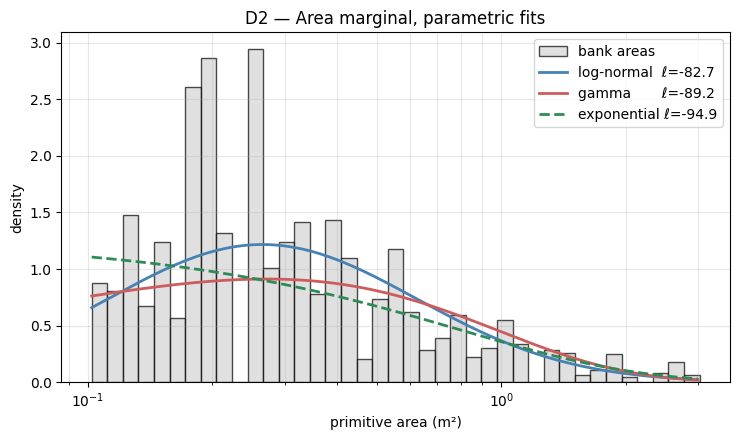

Best log-likelihood : lognorm   Δ over 2nd best = 6.49


In [12]:
from scipy import stats

x = bank_df['area_env_m2'].to_numpy()
x = x[x > 0]

fits = {}
fits['lognorm'] = stats.lognorm.fit(x, floc=0)
fits['gamma']   = stats.gamma.fit  (x, floc=0)
fits['expon']   = stats.expon.fit  (x, floc=0)

ll = {}
ll['lognorm'] = stats.lognorm.logpdf(x, *fits['lognorm']).sum()
ll['gamma']   = stats.gamma  .logpdf(x, *fits['gamma']  ).sum()
ll['expon']   = stats.expon  .logpdf(x, *fits['expon']  ).sum()

fig, ax = plt.subplots(figsize=(7.5, 4.5))
bins = np.logspace(np.log10(x.min()), np.log10(x.max() * 1.01), 40)
ax.hist(x, bins=bins, density=True, color='lightgray', edgecolor='black',
        alpha=0.7, label='bank areas')
xs = np.logspace(np.log10(x.min()), np.log10(x.max()), 300)
ax.plot(xs, stats.lognorm.pdf(xs, *fits['lognorm']), color='steelblue',
        lw=2, label=f"log-normal  ℓ={ll['lognorm']:.1f}")
ax.plot(xs, stats.gamma  .pdf(xs, *fits['gamma']),   color='indianred',
        lw=2, label=f"gamma       ℓ={ll['gamma']:.1f}")
ax.plot(xs, stats.expon  .pdf(xs, *fits['expon']),   color='seagreen',
        lw=2, ls='--', label=f"exponential ℓ={ll['expon']:.1f}")
ax.set_xscale('log')
ax.set_xlabel('primitive area (m²)')
ax.set_ylabel('density')
ax.set_title('D2 — Area marginal, parametric fits')
ax.legend()
ax.grid(alpha=0.3, which='both')
plt.tight_layout(); savefig('D2_area_marginal_fits.png'); plt.show()

best = max(ll, key=ll.get)
print(f'Best log-likelihood : {best}   Δ over 2nd best = '
      f'{ll[best] - sorted(ll.values())[-2]:.2f}')


### D3 — Violin of environment-radius by scale decile

Same shape as the K-sweep violin, x-axis = decile of `radius_env_m` in the
bank (deepest scale spread the tree exposes). Overlay Eliav's 32 m / 200 m
= 16 % and Harland's 3.46 m² / 18.6 m² = 19 % marks as horizontal
guidelines for direct comparison.


Saved → analysis/experiment_multi_field_mixture_bank/figures/D3_radius_by_scale_decile.png


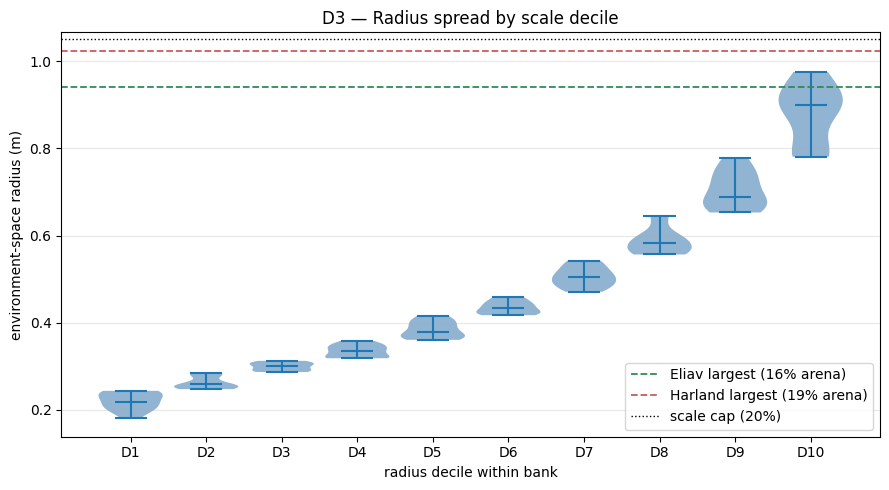

In [13]:
deciles = pd.qcut(bank_df['radius_env_m'], q=10,
                  labels=[f'D{i+1}' for i in range(10)])
grouped = [bank_df.loc[deciles == f'D{i+1}', 'radius_env_m'].to_numpy()
           for i in range(10)]

fig, ax = plt.subplots(figsize=(9, 5))
parts = ax.violinplot(grouped, showmedians=True, widths=0.85)
for pc in parts['bodies']:
    pc.set_facecolor('steelblue'); pc.set_alpha(0.6)
ax.set_xticks(range(1, 11))
ax.set_xticklabels([f'D{i+1}' for i in range(10)])
ax.set_xlabel('radius decile within bank')
ax.set_ylabel('environment-space radius (m)')

# Eliav / Harland fractional caps overlaid
r_eliav   = np.sqrt(0.16 * arena_area / np.pi)     # 16% arena area → equivalent-disc radius
r_harland = np.sqrt(0.19 * arena_area / np.pi)     # 19% arena area
r_cap     = np.sqrt(ARENA_FRAC_CAP * arena_area / np.pi)
ax.axhline(r_eliav,   color='seagreen',  ls='--', lw=1.3, label='Eliav largest (16% arena)')
ax.axhline(r_harland, color='indianred', ls='--', lw=1.3, label='Harland largest (19% arena)')
ax.axhline(r_cap,     color='black',     ls=':',  lw=1.0, label=f'scale cap ({ARENA_FRAC_CAP*100:.0f}%)')
ax.set_title('D3 — Radius spread by scale decile')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); savefig('D3_radius_by_scale_decile.png'); plt.show()


### D4 — Draw simulation (Eliav / Harland go / no-go)

Draw `n̄ = N_MEAN_PRIMITIVES` primitives uniformly at random from the bank,
`N_DRAWS` times. For each draw record:

- **max / min radius ratio**  ← Eliav 2021 convention (radius)
- **max² / min² area ratio**  ← the same ratio expressed in area units,
  for readers who prefer to compare in Harland's convention
- **max − min area (m²)**     ← Harland 2021 convention
- **total area (m²)**         ← sanity check on coverage

Overlay the reference values as vertical lines: Eliav median 4.4 and tail
20 (radius ratio, or 19 / 400 in area units); Harland 0.6 m² area range.
Everything is labeled in both units so no comparison is hidden.


Saved → analysis/experiment_multi_field_mixture_bank/figures/D4_draw_simulation.png


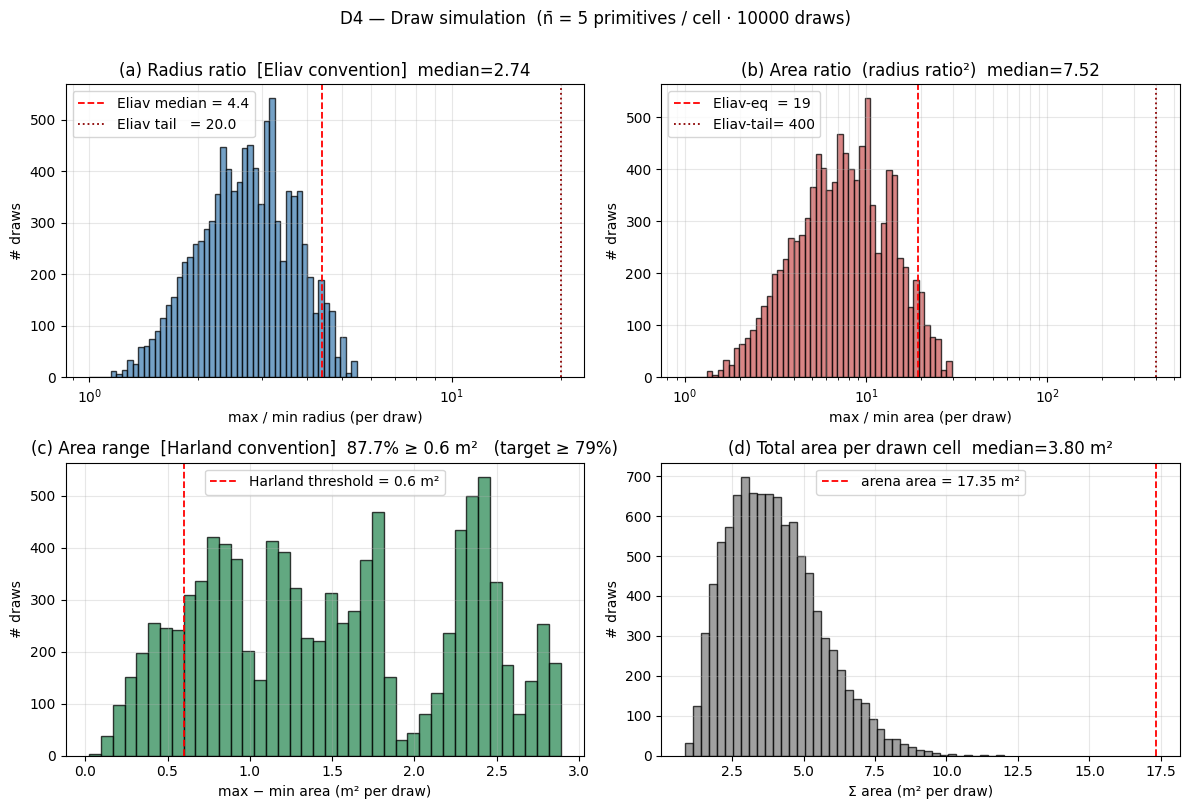


Eliav  target : median radius ratio ≈ 4.4,  tail to 20.0
                observed median = 2.74   99 %ile = 4.97
Harland target: area range > 0.6 m² for ≥ 79% of cells
                observed fraction ≥ 0.6 m² : 87.7%


In [14]:
rng2 = np.random.default_rng(RANDOM_SEED + 1)
r_arr = bank_df['radius_env_m'].to_numpy()
a_arr = bank_df['area_env_m2'].to_numpy()

# Uniform-with-replacement draws over the bank
idx = rng2.integers(0, len(r_arr), size=(N_DRAWS, N_MEAN_PRIMITIVES))
r_draws = r_arr[idx]              # (N_DRAWS, n̄)
a_draws = a_arr[idx]

r_ratio  = r_draws.max(1) / np.clip(r_draws.min(1), 1e-9, None)
a_ratio  = a_draws.max(1) / np.clip(a_draws.min(1), 1e-9, None)
a_range  = a_draws.max(1) - a_draws.min(1)
a_total  = a_draws.sum(1)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# (a) radius ratio — Eliav convention
ax = axes[0, 0]
ax.hist(r_ratio, bins=np.logspace(0, np.log10(r_ratio.max()*1.01), 50),
        color='steelblue', edgecolor='black', alpha=0.75)
ax.axvline(ELIAV_MEDIAN_RATIO, color='red',  ls='--', lw=1.3,
           label=f'Eliav median = {ELIAV_MEDIAN_RATIO}')
ax.axvline(ELIAV_TAIL_RATIO,   color='darkred', ls=':', lw=1.3,
           label=f'Eliav tail   = {ELIAV_TAIL_RATIO}')
ax.set_xscale('log'); ax.set_xlabel('max / min radius (per draw)'); ax.set_ylabel('# draws')
ax.legend(); ax.grid(alpha=0.3, which='both')
ax.set_title(f'(a) Radius ratio  [Eliav convention]  median={np.median(r_ratio):.2f}')

# (b) area ratio — Harland-style expression of the same underlying draws
ax = axes[0, 1]
ax.hist(a_ratio, bins=np.logspace(0, np.log10(a_ratio.max()*1.01), 50),
        color='indianred', edgecolor='black', alpha=0.75)
ax.axvline(ELIAV_MEDIAN_RATIO ** 2, color='red',  ls='--', lw=1.3,
           label=f'Eliav-eq  = {ELIAV_MEDIAN_RATIO**2:.0f}')
ax.axvline(ELIAV_TAIL_RATIO   ** 2, color='darkred', ls=':',  lw=1.3,
           label=f'Eliav-tail= {ELIAV_TAIL_RATIO**2:.0f}')
ax.set_xscale('log'); ax.set_xlabel('max / min area (per draw)'); ax.set_ylabel('# draws')
ax.legend(); ax.grid(alpha=0.3, which='both')
ax.set_title(f'(b) Area ratio  (radius ratio²)  median={np.median(a_ratio):.2f}')

# (c) area range — Harland convention
ax = axes[1, 0]
ax.hist(a_range, bins=40, color='seagreen', edgecolor='black', alpha=0.75)
ax.axvline(HARLAND_AREA_RANGE, color='red', ls='--', lw=1.3,
           label=f'Harland threshold = {HARLAND_AREA_RANGE} m²')
frac_above = float((a_range > HARLAND_AREA_RANGE).mean())
ax.set_xlabel('max − min area (m² per draw)'); ax.set_ylabel('# draws')
ax.legend(); ax.grid(alpha=0.3)
ax.set_title(f'(c) Area range  [Harland convention]  '
             f'{frac_above*100:.1f}% ≥ {HARLAND_AREA_RANGE} m²   '
             f'(target ≥ {HARLAND_TARGET_FRAC*100:.0f}%)')

# (d) total area per cell — coverage sanity
ax = axes[1, 1]
ax.hist(a_total, bins=40, color='gray', edgecolor='black', alpha=0.75)
ax.axvline(arena_area, color='red', ls='--', lw=1.3,
           label=f'arena area = {arena_area:.2f} m²')
ax.set_xlabel('Σ area (m² per draw)'); ax.set_ylabel('# draws')
ax.legend(); ax.grid(alpha=0.3)
ax.set_title(f'(d) Total area per drawn cell  median={np.median(a_total):.2f} m²')

fig.suptitle(f'D4 — Draw simulation  '
             f'(n̄ = {N_MEAN_PRIMITIVES} primitives / cell · {N_DRAWS} draws)',
             y=1.005)
plt.tight_layout(); savefig('D4_draw_simulation.png'); plt.show()

print()
print(f'Eliav  target : median radius ratio ≈ {ELIAV_MEDIAN_RATIO},  tail to {ELIAV_TAIL_RATIO}')
print(f'                observed median = {np.median(r_ratio):.2f}   '
      f'99 %ile = {np.quantile(r_ratio, 0.99):.2f}')
print(f'Harland target: area range > {HARLAND_AREA_RANGE} m² for '
      f'≥ {HARLAND_TARGET_FRAC*100:.0f}% of cells')
print(f'                observed fraction ≥ {HARLAND_AREA_RANGE} m² : {frac_above*100:.1f}%')


### D5 — Spatial dispersion

Nearest-neighbour distance between primitive centroids, split by scale
band (quartile of `radius_env_m`). If small-scale primitives are strongly
clustered spatially (low mean NN distance), uniform draws from the bank
won't give Poisson-like subfield placement and pooling will need to inject
extra jitter or reject-sample.


/var/folders/k9/tcxpg_fx3d3blrkql_1z83wh0000gn/T/ipykernel_24614/1825583168.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([s if len(s) else [np.nan] for s in nn_stats], labels=labels_)


Saved → analysis/experiment_multi_field_mixture_bank/figures/D5_spatial_dispersion.png


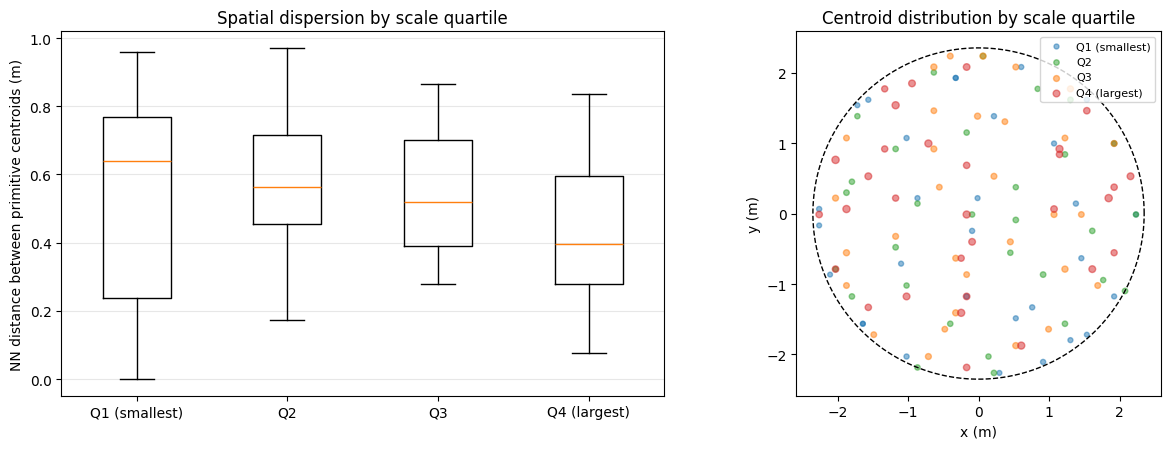

  Q1 (smallest)    n=  31  NN median=0.639  IQR=[0.239, 0.767]
  Q2               n=  30  NN median=0.564  IQR=[0.455, 0.715]
  Q3               n=  31  NN median=0.520  IQR=[0.391, 0.702]
  Q4 (largest)     n=  31  NN median=0.395  IQR=[0.279, 0.595]


In [15]:
from scipy.spatial import cKDTree

q = np.quantile(bank_df['radius_env_m'], [0.25, 0.5, 0.75])
labels_ = ['Q1 (smallest)', 'Q2', 'Q3', 'Q4 (largest)']
bands_ = [
    bank_df[bank_df['radius_env_m'] <  q[0]],
    bank_df[(bank_df['radius_env_m'] >= q[0]) & (bank_df['radius_env_m'] < q[1])],
    bank_df[(bank_df['radius_env_m'] >= q[1]) & (bank_df['radius_env_m'] < q[2])],
    bank_df[bank_df['radius_env_m'] >= q[2]],
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# (a) NN distance by scale band
nn_stats = []
for lab, band in zip(labels_, bands_):
    if len(band) < 2:
        nn_stats.append([]); continue
    pts = band[['centroid_x', 'centroid_y']].to_numpy()
    tree = cKDTree(pts)
    d, _ = tree.query(pts, k=2)  # k=1 is the point itself
    nn_stats.append(d[:, 1])

axes[0].boxplot([s if len(s) else [np.nan] for s in nn_stats], labels=labels_)
axes[0].set_ylabel('NN distance between primitive centroids (m)')
axes[0].set_title('Spatial dispersion by scale quartile')
axes[0].grid(alpha=0.3, axis='y')

# (b) centroid scatter, sized by radius
ax = axes[1]
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']
for lab, band, c in zip(labels_, bands_, colors):
    ax.scatter(band['centroid_x'], band['centroid_y'],
               s=8 + 20 * band['radius_env_m'], color=c, alpha=0.5, label=lab)
theta_ring = np.linspace(0, 2*np.pi, 200)
ax.plot(arena_radius * np.cos(theta_ring), arena_radius * np.sin(theta_ring),
        color='black', lw=1.0, ls='--')
ax.set_aspect('equal'); ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_title('Centroid distribution by scale quartile')
ax.legend(loc='upper right', fontsize=8)

plt.tight_layout(); savefig('D5_spatial_dispersion.png'); plt.show()

for lab, s in zip(labels_, nn_stats):
    if len(s):
        print(f'  {lab:15s}  n={len(s):4d}  '
              f'NN median={np.median(s):.3f}  IQR=[{np.quantile(s, 0.25):.3f}, {np.quantile(s, 0.75):.3f}]')
    else:
        print(f'  {lab:15s}  (empty)')


## Summary

- Bank artifact at `data_cache/multi_field_bank/bank.csv` — one row
  per surviving primitive, downstream experiments M1–M5 load from here.
- Radius cap (≈ 20 % arena, ≈ 1.0 m in LM8) derived from Eliav/Harland
  data, not chosen — excludes the K = 10–50 near-global level of the
  K-sweep entirely.
- D4 reports the go / no-go signal in both conventions:
  - Eliav radius ratio, median target 4.4 (tail 20)
  - Harland area range, target > 0.6 m² for ≥ 79 % of cells
